In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

pd.set_option('display.max_columns', 20)
plt.style.use('ggplot')

In [2]:
# dataset used for the excel sheet
# https://www.kaggle.com/datasets/timospinde/babe-media-bias-annotations-by-experts?select=data

In [3]:
babe = pd.read_excel("final_labels_SG2.xlsx")

babe.head()

,text,news_link,outlet,topic,type,label_bias,label_opinion,biased_words
0,"""Orange Is the New Black"" star Yael Stone is r...",https://www.foxnews.com/entertainment/australi...,Fox News,environment,right,Non-biased,Entirely factual,[]
1,"""We have one beautiful law,"" Trump recently sa...",https://www.alternet.org/2020/06/law-and-order...,Alternet,gun control,left,Biased,Somewhat factual but also opinionated,"['bizarre', 'characteristically']"
2,"...immigrants as criminals and eugenics, all o...",https://www.nbcnews.com/news/latino/after-step...,MSNBC,white-nationalism,left,Biased,Expresses writer’s opinion,"['criminals', 'fringe', 'extreme']"
3,...we sounded the alarm in the early months of...,https://www.alternet.org/2019/07/fox-news-has-...,Alternet,white-nationalism,left,Biased,Somewhat factual but also opinionated,[]
4,[Black Lives Matter] is essentially a non-fals...,http://feedproxy.google.com/~r/breitbart/~3/-v...,Breitbart,marriage-equality,NaN,Biased,Expresses writer’s opinion,['cult']


In [4]:
babe = babe[["text", "label_bias"]].dropna()

babe["label"] = babe["label_bias"].map({
    "Biased": 1,
    "Non-biased": 0
})

babe = babe.dropna(subset=["label"])
babe["label"] = babe["label"].astype(int)

babe.head()

,text,label_bias,label
0,"""Orange Is the New Black"" star Yael Stone is r...",Non-biased,0
1,"""We have one beautiful law,"" Trump recently sa...",Biased,1
2,"...immigrants as criminals and eugenics, all o...",Biased,1
3,...we sounded the alarm in the early months of...,Biased,1
4,[Black Lives Matter] is essentially a non-fals...,Biased,1


In [5]:
babe["label_bias"].value_counts()

label_bias
Non-biased    1863
Biased        1810
Name: count, dtype: int64

In [6]:
X = babe["text"]
y = babe["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [8]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_vec, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [9]:
y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()

print(classification_report(
    y_test,
    y_pred,
    target_names=["Non-biased", "Biased"]
))

print(confusion_matrix(y_test, y_pred))

Accuracy: 0.726530612244898

              precision    recall  f1-score   support

  Non-biased       0.73      0.73      0.73       373
      Biased       0.72      0.72      0.72       362

    accuracy                           0.73       735
   macro avg       0.73      0.73      0.73       735
weighted avg       0.73      0.73      0.73       735

[[274  99]
 [102 260]]


In [10]:
news = pd.read_csv("allsides_balanced_news_headlines-texts.csv")

news.head()

,Unnamed: 0,title,tags,heading,source,text,bias_rating
0,0,Gun Violence Over Fourth of July Weekend,"['Protests', 'Fourth Of July', 'Gun Control An...",Chicago Gun Violence Spikes and Increasingly F...,New York Times (News),As Yasmin Miller drove home from a laundromat ...,left
1,1,Gun Violence Over Fourth of July Weekend,"['Protests', 'Fourth Of July', 'Gun Control An...",‘Bullets just came from nowhere’: Fourth of Ju...,Chicago Tribune,As many Chicagoans were celebrating the Fourth...,center
2,2,Gun Violence Over Fourth of July Weekend,"['Protests', 'Fourth Of July', 'Gun Control An...",Dozens of shootings across US mark bloody July...,New York Post (News),The nation’s 4th of July weekend was marred by...,right
3,3,Yellen Warns Congress of 'Economic Recession' ...,"['Janet Yellen', 'Debt Ceiling', 'Economic Pol...",Federal Government Will Run Out of Cash on Oct...,The Epoch Times,Treasury Secretary Janet Yellen on Tuesday war...,right
4,4,Yellen Warns Congress of 'Economic Recession' ...,"['Janet Yellen', 'Debt Ceiling', 'Economic Pol...",Yellen tells Congress that U.S. will run out o...,Washington Post,Treasury Secretary Janet Yellen on Tuesday tol...,left


In [11]:
news = news.dropna(subset=["text"]).copy()

X_news_vec = vectorizer.transform(news["text"])

news["predicted_bias_label"] = model.predict(X_news_vec)

news["predicted_bias"] = news["predicted_bias_label"].map({
    0: "Non-biased",
    1: "Biased"
})

news["bias_probability"] = model.predict_proba(X_news_vec)[:, 1]

news[[
    "title",
    "source",
    "bias_rating",
    "predicted_bias",
    "bias_probability"
]].head()

,title,source,bias_rating,predicted_bias,bias_probability
0,Gun Violence Over Fourth of July Weekend,New York Times (News),left,Non-biased,0.285851
1,Gun Violence Over Fourth of July Weekend,Chicago Tribune,center,Non-biased,0.358307
2,Gun Violence Over Fourth of July Weekend,New York Post (News),right,Non-biased,0.210504
3,Yellen Warns Congress of 'Economic Recession' ...,The Epoch Times,right,Non-biased,0.385014
4,Yellen Warns Congress of 'Economic Recession' ...,Washington Post,left,Non-biased,0.356977


In [12]:
news_sorted = news.sort_values(
    "bias_probability",
    ascending=False
)

news_sorted[[
    "title",
    "source",
    "bias_rating",
    "predicted_bias",
    "bias_probability"
]].head(20)

,title,source,bias_rating,predicted_bias,bias_probability
9332,New York Governor Andrew Cuomo Wins Gubernator...,Vox,left,Biased,0.910965
13943,Analysis of Georgia Election,The Hill,center,Biased,0.883960
722,Sessions Tapped as Attorney General,HuffPost,left,Biased,0.871421
14275,"Perspectives: Will Kasich, Never Trumpers Triu...",National Review,right,Biased,0.858512
6017,Trump Backs Out of Debate,Media Matters,left,Biased,0.856349
11302,New York Times Flip-Flops on Tom Cotton's Op-Ed,Michelle Goldberg,left,Biased,0.849134
20288,Perspectives: Canceling Cancel Culture,Washington Post,left,Biased,0.847904
21589,Leaked Disney Videos Spark Debate Over Woke Cu...,CNN (Opinion),left,Biased,0.845964
12208,Donald: Helping or Hurting,CNN (Online News),left,Biased,0.839900
3555,Benghazi Back in the News,CNN (Online News),left,Biased,0.838332


we're gonna see the distribution of bias_probbilities across differernt bias_ratings

In [13]:
news_sorted['bias_rating'].value_counts()

bias_rating
left      10273
right      7222
center     4252
Name: count, dtype: int64

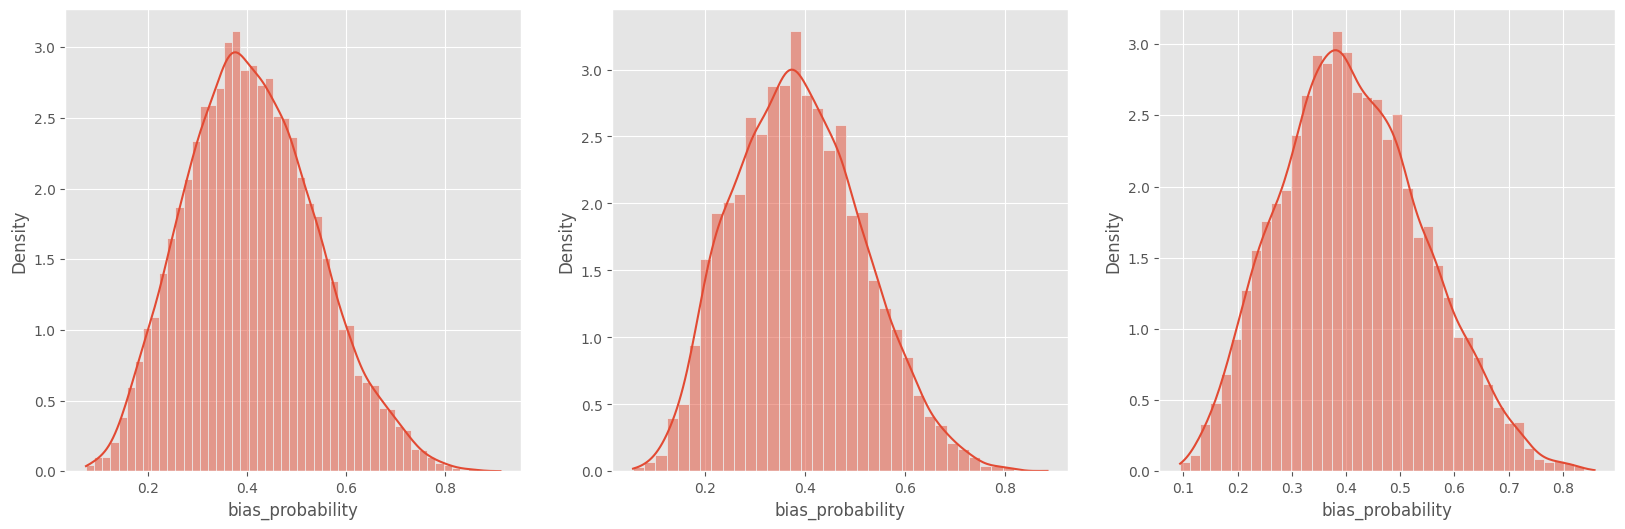

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

bias_ratings = ['left', 'center', 'right']

for rating in bias_ratings:
    sns.histplot(news_sorted[news_sorted['bias_rating'] == rating]['bias_probability'], ax=ax[bias_ratings.index(rating)], kde=True, stat="density")
